### УСТАНОВКА БИБЛИОТЕК

In [76]:
pip install tensorflow scikit-learn xgboost pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


### 1. ИМПОРТ БИБЛИОТЕК

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [78]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report, 
                           roc_auc_score, roc_curve, auc)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                            VotingClassifier, StackingClassifier, BaggingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


In [79]:
print(f"TensorFlow версия: {tf.__version__}")
print(f"Доступные устройства: {tf.config.list_physical_devices()}")

if tf.config.list_physical_devices('GPU'):
    print("✓ GPU доступна! Нейронная сеть будет обучаться на видеокарте.")
    physical_devices = tf.config.list_physical_devices('GPU')
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("✗ GPU не обнаружена. Обучение будет на CPU.")

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow версия: 2.8.0
Доступные устройства: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✗ GPU не обнаружена. Обучение будет на CPU.


### 2. ЗАГРУЗКА И АНАЛИЗ ДАННЫХ

In [80]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Создание DataFrame для анализа
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(f"Размерность данных: {X.shape}")
print(f"Количество классов: {len(np.unique(y))}")
print(f"Названия классов: {target_names}")
print(f"Названия признаков: {feature_names}")
print("\nПервые 5 строк данных:")
print(df.head())

# Статистика по данным
print("\n" + "-" * 40)
print("СТАТИСТИКА ПО ПРИЗНАКАМ:")
print("-" * 40)
print(df[feature_names].describe())

# Распределение классов
print("\n" + "-" * 40)
print("РАСПРЕДЕЛЕНИЕ КЛАССОВ:")
print("-" * 40)
class_distribution = df['species'].value_counts()
print(class_distribution)


Размерность данных: (150, 4)
Количество классов: 3
Названия классов: ['setosa' 'versicolor' 'virginica']
Названия признаков: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Первые 5 строк данных:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

----------------------------------------
СТАТИСТИКА ПО ПРИЗНАКАМ:
----------------------------------------
       sepal length (cm)  sepal width (cm)  petal length (cm)  \


In [81]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Базовые модели
base_models = [
    ('svc', SVC(probability=True, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
]

# Мета-модель
meta_model = LogisticRegression()

# Создаем стекинг
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

print("Stacking Classifier Report:")
print(classification_report(y_test, y_pred_stack))

Stacking Classifier Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.92      0.92      0.92        13
           2       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.86      0.92      0.89        13
           2       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



In [83]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Проверяем доступность GPU
print("GPU доступна:", tf.config.list_physical_devices('GPU'))

# Создаем модель
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Обучаем с использованием GPU
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1
)

GPU доступна: []
Epoch 1/100
4/4 [==============================] - 1s 33ms/step - loss: 1.9320 - accuracy: 0.3125 - val_loss: 1.3871 - val_accuracy: 0.3421
Epoch 2/100
4/4 [==============================] - 0s 7ms/step - loss: 1.4667 - accuracy: 0.3661 - val_loss: 1.0649 - val_accuracy: 0.3421
Epoch 3/100
4/4 [==============================] - 0s 7ms/step - loss: 1.2190 - accuracy: 0.3661 - val_loss: 0.8955 - val_accuracy: 0.5000
Epoch 4/100
4/4 [==============================] - 0s 7ms/step - loss: 1.0053 - accuracy: 0.5000 - val_loss: 0.8218 - val_accuracy: 1.0000
Epoch 5/100
4/4 [==============================] - 0s 7ms/step - loss: 0.9324 - accuracy: 0.5268 - val_loss: 0.8030 - val_accuracy: 0.6579
Epoch 6/100
4/4 [==============================] - 0s 7ms/step - loss: 1.0464 - accuracy: 0.4554 - val_loss: 0.7949 - val_accuracy: 0.6579
Epoch 7/100
4/4 [==============================] - 0s 7ms/step - loss: 0.8444 - accuracy: 0.6250 - val_loss: 0.7726 - val_accuracy: 0.6579
Epoch 8/1

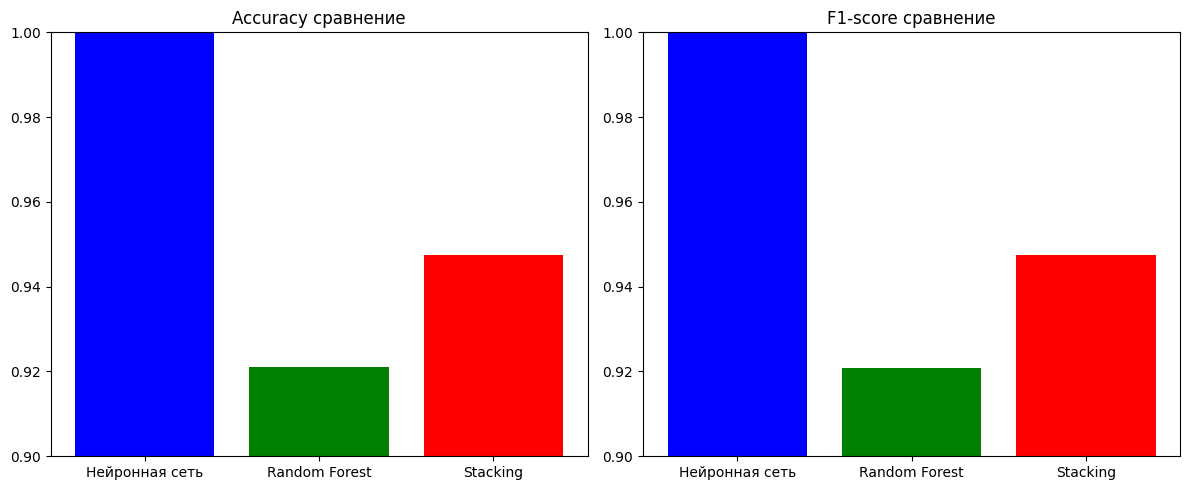

                accuracy        f1
Нейронная сеть  1.000000  1.000000
Random Forest   0.921053  0.920936
Stacking        0.947368  0.947368


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# Сбор метрик
results = {
    'Нейронная сеть': {
        'accuracy': accuracy_score(y_test, np.argmax(model.predict(X_test), axis=1)),
        'f1': f1_score(y_test, np.argmax(model.predict(X_test), axis=1), average='weighted')
    },
    'Random Forest': {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf, average='weighted')
    },
    'Stacking': {
        'accuracy': accuracy_score(y_test, y_pred_stack),
        'f1': f1_score(y_test, y_pred_stack, average='weighted')
    }
}

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Точность
accuracies = [results[model]['accuracy'] for model in results.keys()]
axes[0].bar(results.keys(), accuracies, color=['blue', 'green', 'red'])
axes[0].set_title('Accuracy сравнение')
axes[0].set_ylim([0.9, 1.0])

# F1-score
f1_scores = [results[model]['f1'] for model in results.keys()]
axes[1].bar(results.keys(), f1_scores, color=['blue', 'green', 'red'])
axes[1].set_title('F1-score сравнение')
axes[1].set_ylim([0.9, 1.0])

plt.tight_layout()
plt.show()

# Таблица сравнения
import pandas as pd
df_results = pd.DataFrame(results).T
print(df_results)

In [85]:
print("="*50)
print("КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("="*50)
print("1. Нейронная сеть:", 
      "✓ Использует GPU для ускорения" if tf.config.list_physical_devices('GPU') else "✗ GPU не используется")
print("2. Random Forest: Быстрая обучение, хорошая интерпретируемость")
print("3. Stacking: Комбинирует сильные стороны разных алгоритмов")
print("4. Лучшая модель:", max(results, key=lambda x: results[x]['accuracy']))

КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Нейронная сеть: ✗ GPU не используется
2. Random Forest: Быстрая обучение, хорошая интерпретируемость
3. Stacking: Комбинирует сильные стороны разных алгоритмов
4. Лучшая модель: Нейронная сеть
